# MLP trined to predict data from the MNIST dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from mlp import MLP, Layer
from activations import Relu, SoftMax
from losses import CrossEntropyLoss
from utils import OneHotEncoder

In [4]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.to_numpy() / 255.0
Y = mnist.target.astype(int).to_numpy()

encoder = OneHotEncoder()

Y = encoder.encode(Y, num_classes=10)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = Y[:60000], Y[60000:]

In [5]:
mlp = MLP()
mlp.add_layer(Layer(784, 128, Relu()))
mlp.add_layer(Layer(128, 64, Relu()))
mlp.add_layer(Layer(64, 10, SoftMax()))

loss_fn = CrossEntropyLoss()
learning_rate = 0.5

In [54]:
epochs = 30
losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for x, y_true in zip(X_train, y_train):
        y_pred = mlp.forward(x)
        epoch_loss += loss_fn.forward(y_pred, y_true)
        delta = loss_fn.backward(y_pred, y_true)
        mlp.backward(delta)
        mlp.update(learning_rate)
    
    losses.append(epoch_loss / len(X_train))
    print(f"Epoch {epoch+1}/{epochs}  Loss: {losses[-1]}")


Epoch 1/30  Loss: 16.602252542203477
Epoch 2/30  Loss: 16.602252542203477
Epoch 3/30  Loss: 16.602252542203477
Epoch 4/30  Loss: 16.602252542203477
Epoch 5/30  Loss: 16.602252542203477
Epoch 6/30  Loss: 16.602252542203477
Epoch 7/30  Loss: 16.602252542203477
Epoch 8/30  Loss: 16.602252542203477
Epoch 9/30  Loss: 16.602252542203477
Epoch 10/30  Loss: 16.602252542203477
Epoch 11/30  Loss: 16.602252542203477
Epoch 12/30  Loss: 16.602252542203477
Epoch 13/30  Loss: 16.602252542203477
Epoch 14/30  Loss: 16.602252542203477
Epoch 15/30  Loss: 16.602252542203477
Epoch 16/30  Loss: 16.602252542203477
Epoch 17/30  Loss: 16.602252542203477
Epoch 18/30  Loss: 16.602252542203477
Epoch 19/30  Loss: 16.602252542203477
Epoch 20/30  Loss: 16.602252542203477
Epoch 21/30  Loss: 16.602252542203477
Epoch 22/30  Loss: 16.602252542203477
Epoch 23/30  Loss: 16.602252542203477
Epoch 24/30  Loss: 16.602252542203477
Epoch 25/30  Loss: 16.602252542203477
Epoch 26/30  Loss: 16.602252542203477
Epoch 27/30  Loss: 16

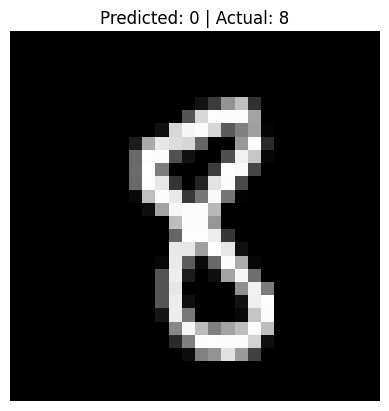

Predicted: 0 | Actual: 8


In [77]:
index = np.random.randint(0, len(X_test))
x = X_test[index]
y_true = y_test[index]

y_pred = mlp.forward(x)
predicted = np.argmax(y_pred)
actual = np.argmax(y_true)

image = x.reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.title(f"Predicted: {predicted} | Actual: {actual}")
plt.axis('off')
plt.show()
print(f"Predicted: {predicted} | Actual: {actual}")